# Introduction to Ensemble Models
**Ensemble models** use multiple base models (weak learners) to create a single enhance model.

## Bagging
**Bagging** *(bootstrap + aggregating)*: ensemble method that uses **bootstrap resampling**, which is random sampling with replacement, to learn several models on random variations of the training set. In other words, many models are made on different subsets of the training set. Then, the predictions of each learner are **aggregated** to give the final prediction. In classification, it is the majority vote of the class prediction; in regression, it is the average of the predicted values.

In [1]:
import pandas as pd
import numpy as np
from pyparsing import col


def generate_data(n_samples=30):
    """Generate synthetic dataset. Returns `data_train`, `data_test`,
    `target_train`."""
    x_min, x_max = -3, 3
    rng = np.random.default_rng(1)  # Create a random number generator
    x = rng.uniform(x_min, x_max, size=n_samples)
    noise = 4.0 * rng.normal(size=(n_samples,))
    y = x**3 - 0.5 * (x + 1) ** 2 + noise
    y /= y.std()

    data_train = pd.DataFrame(x, columns=["Feature"])
    data_test = pd.DataFrame(
        np.linspace(x_max, x_min, num=300), columns=["Feature"]
    )
    target_train = pd.Series(y, name="Target")

    return data_train, data_test, target_train

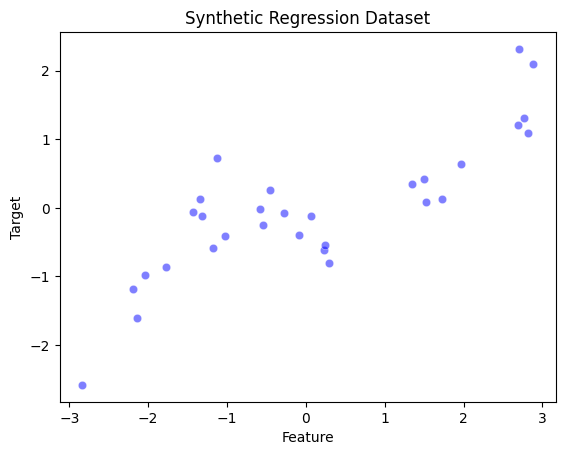

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

X_train, X_test, y_train = generate_data(n_samples=30)
sns.scatterplot(
    x=X_train["Feature"], y=y_train, color="blue", alpha=0.5
)
_ = plt.title("Synthetic Regression Dataset")

### Single Decision Tree
Here, we can see the results of using a single decision tree regressor.

In [8]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3, random_state=0)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

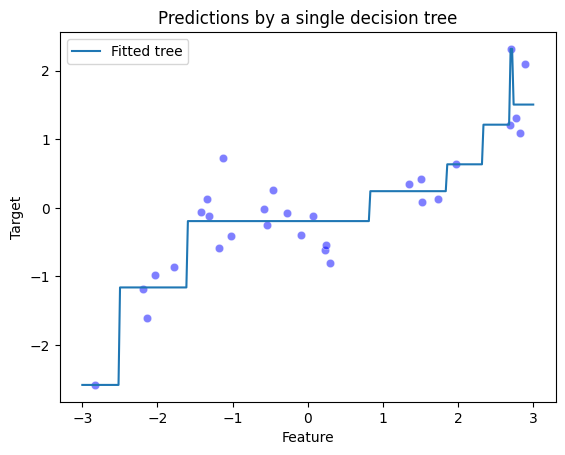

In [9]:
sns.scatterplot(
    x=X_train["Feature"], y=y_train, color="blue", alpha=0.5
)
plt.plot(X_test["Feature"], y_pred, label="Fitted tree")
plt.legend()
_ = plt.title("Predictions by a single decision tree")

### Using Bootstrapping
Bootstrapping involves uniformly resampling `n` data points from a dataset of `n` points, with replacement, ensuring each sample has an equal chance of selection.

Thus, the output of bootstrapping is another data set of `n` points, likely with some duplicates. Excluded data points are often called the *out-of-bag sample*.

In [10]:
def bootstrap_sample(data, target, seed=0):
    # Indices corresponding to a sampling with replacement of the same sample
    # size than the original data
    rng = np.random.default_rng(seed)
    bootstrap_indices = rng.choice(
        np.arange(target.shape[0]),
        size=target.shape[0],
        replace=True,
    )
    # In pandas, we need to use `.iloc` to extract rows using an integer
    # position index:
    data_bootstrap = data.iloc[bootstrap_indices]
    target_bootstrap = target.iloc[bootstrap_indices]
    return data_bootstrap, target_bootstrap

Below, we visualize 3 bootstrap samples to see the difference between the sampled set and the original set.

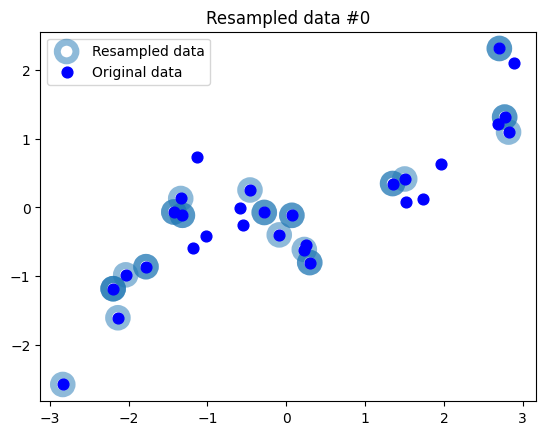

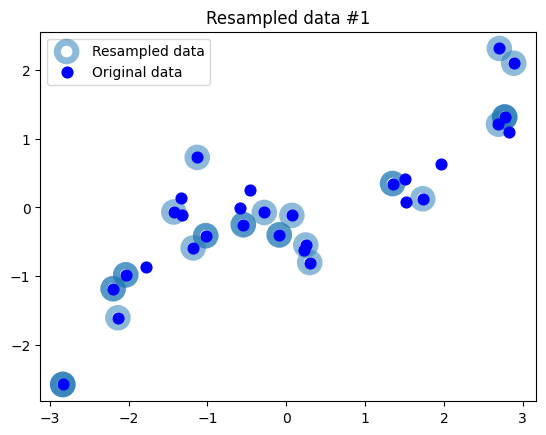

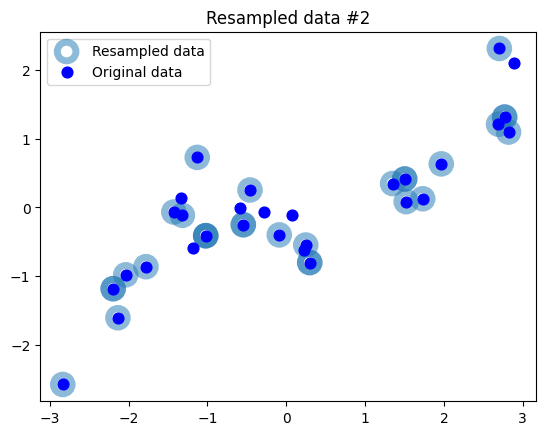

In [11]:
n_bootstraps = 3
for bootstrap_idx in range(n_bootstraps):
    # draw a bootstrap from the original data
    data_bootstrap, target_bootstrap = bootstrap_sample(
        X_train,
        y_train,
        seed=bootstrap_idx,  # ensure bootstrap samples are different but reproducible
    )
    plt.figure()
    plt.scatter(
        data_bootstrap["Feature"],
        target_bootstrap,
        color="tab:blue",
        facecolors="none",
        alpha=0.5,
        label="Resampled data",
        s=180,
        linewidth=5,
    )
    plt.scatter(
        X_train["Feature"],
        y_train,
        color="blue",
        s=60,
        alpha=1,
        label="Original data",
    )
    plt.title(f"Resampled data #{bootstrap_idx}")
    plt.legend()

Now, we can fit a decision tree for each of the bootstrapped samples that should be different.

In [12]:
bag_of_trees = []
for bootstrap_idx in range(n_bootstraps):
    tree = DecisionTreeRegressor(max_depth=3, random_state=0)

    data_bootstrap_sample, target_bootstrap_sample = bootstrap_sample(
        X_train, y_train, seed=bootstrap_idx
    )
    tree.fit(data_bootstrap_sample, target_bootstrap_sample)
    bag_of_trees.append(tree)

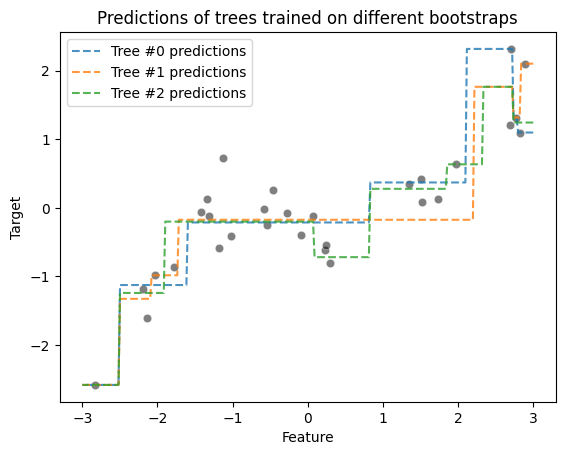

In [14]:
sns.scatterplot(
    x=X_train["Feature"], y=y_train, color="black", alpha=0.5
)
for tree_idx, tree in enumerate(bag_of_trees):
    tree_predictions = tree.predict(X_test)
    plt.plot(
        X_test["Feature"],
        tree_predictions,
        linestyle="--",
        alpha=0.8,
        label=f"Tree #{tree_idx} predictions",
    )

plt.legend()
_ = plt.title("Predictions of trees trained on different bootstraps")

### Aggregating
Now that the trees are fitted, we can get predictions from each and average them.

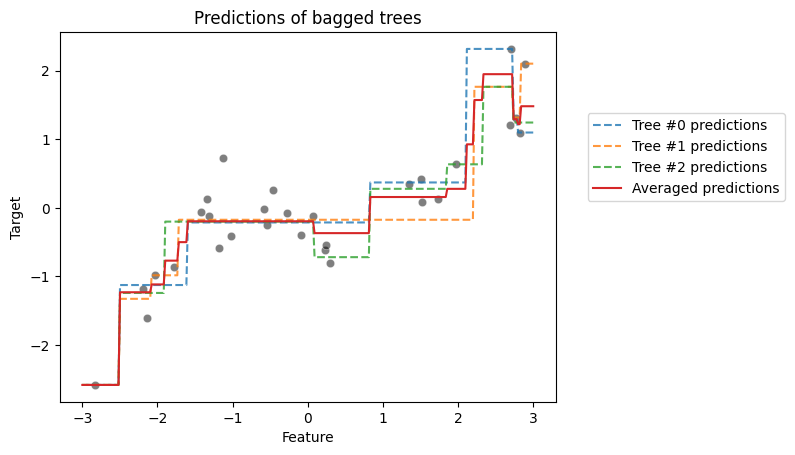

In [15]:
sns.scatterplot(
    x=X_train["Feature"], y=y_train, color="black", alpha=0.5
)

bag_predictions = []
for tree_idx, tree in enumerate(bag_of_trees):
    tree_predictions = tree.predict(X_test)
    plt.plot(
        X_test["Feature"],
        tree_predictions,
        linestyle="--",
        alpha=0.8,
        label=f"Tree #{tree_idx} predictions",
    )
    bag_predictions.append(tree_predictions)

bag_predictions = np.mean(bag_predictions, axis=0)
plt.plot(
    X_test["Feature"],
    bag_predictions,
    label="Averaged predictions",
    linestyle="-",
)
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Predictions of bagged trees")

### Bagging Regressor
Obviously, this process is simplified with scikit-learn types. Specifically, the `BaggingRegressor` is a type of **meta-estimator**: an estimator that wraps another estimator.

In [16]:
from sklearn.ensemble import BaggingRegressor

bagged_trees = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=100
)
_ = bagged_trees.fit(X_train, y_train)

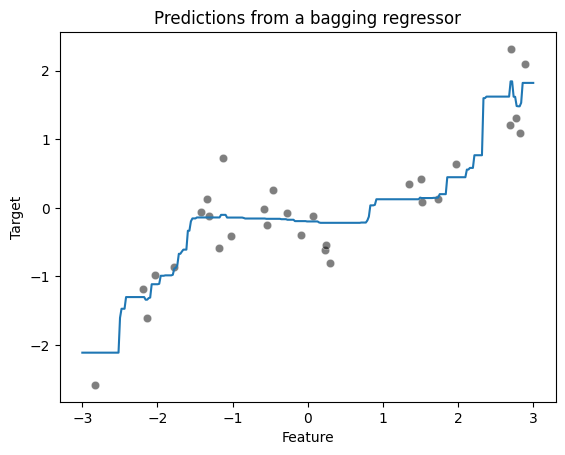

In [17]:
sns.scatterplot(
    x=X_train["Feature"], y=y_train, color="black", alpha=0.5
)

bagged_trees_predictions = bagged_trees.predict(X_test)
plt.plot(X_test["Feature"], bagged_trees_predictions)

_ = plt.title("Predictions from a bagging regressor")

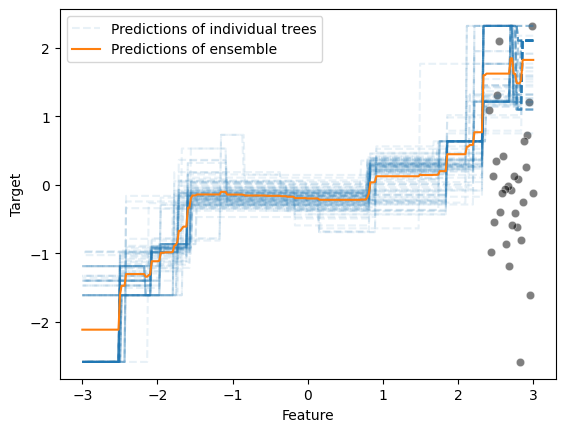

In [18]:
for tree_idx, tree in enumerate(bagged_trees.estimators_):
    label = "Predictions of individual trees" if tree_idx == 0 else None
    # we convert `data_test` into a NumPy array to avoid a warning raised in scikit-learn
    tree_predictions = tree.predict(X_test.to_numpy())
    plt.plot(
        X_test["Feature"],
        tree_predictions,
        linestyle="--",
        alpha=0.1,
        color="tab:blue",
        label=label,
    )

sns.scatterplot(
    x=X_test["Feature"], y=y_train, color="black", alpha=0.5
)

bagged_trees_predictions = bagged_trees.predict(X_test)
plt.plot(
    X_test["Feature"],
    bagged_trees_predictions,
    color="tab:orange",
    label="Predictions of ensemble",
)
_ = plt.legend()

### Bagging Complex Pipelines
Here, we try to showcase how bagging can be used for other models, like a polynomial regression.

In [19]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.pipeline import make_pipeline

polynomial_regressor = make_pipeline(
    MinMaxScaler(),
    PolynomialFeatures(degree=4, include_bias=False),
    Ridge(alpha=1e-10),
)

In [20]:
bagging = BaggingRegressor(
    estimator=polynomial_regressor,
    n_estimators=100,
    random_state=0,
)
_ = bagging.fit(X_train, y_train)

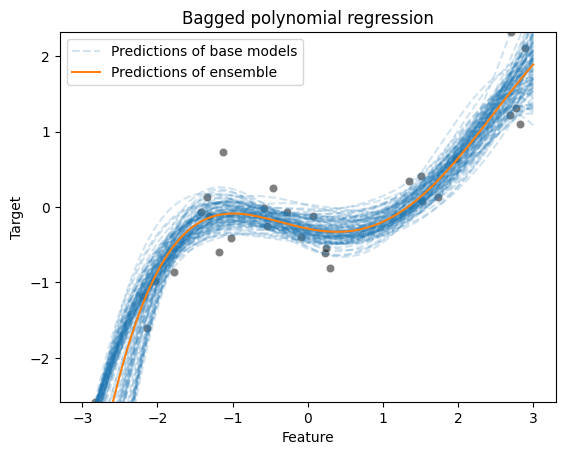

In [22]:
for i, regressor in enumerate(bagging.estimators_):
    # we convert `data_test` into a NumPy array to avoid a warning raised in scikit-learn
    regressor_predictions = regressor.predict(X_test.to_numpy())
    base_model_line = plt.plot(
        X_test["Feature"],
        regressor_predictions,
        linestyle="--",
        alpha=0.2,
        label="Predictions of base models" if i == 0 else None,
        color="tab:blue",
    )

sns.scatterplot(
    x=X_train["Feature"], y=y_train, color="black", alpha=0.5
)
bagging_predictions = bagging.predict(X_test)
plt.plot(
    X_test["Feature"],
    bagging_predictions,
    color="tab:orange",
    label="Predictions of ensemble",
)
plt.ylim(y_train.min(), y_train.max())
plt.legend()
_ = plt.title("Bagged polynomial regression")